## Graph V

### Looping Graph

In [19]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, List
from IPython.display import display, Image
import random

In [20]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int


In [21]:
def greeting_node(state: AgentState) -> AgentState:
    """" Generate Greeting Node """
    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] += 0
    return state


def random_node(state: AgentState) -> AgentState:
    """Generate a random number from 1,10"""
    state["number"].append(random.randint(1, 10))
    state["counter"] += 1
    return state


def should_continue(state: AgentState) -> AgentState:
    """function to decide the next state"""
    if state["counter"] < 5:
        print(f"Entering loop: {state["counter"]}")
        return "loop"
    else:
        return "exit"


In [22]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")
graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)
graph.set_entry_point("greeting")
app = graph.compile()

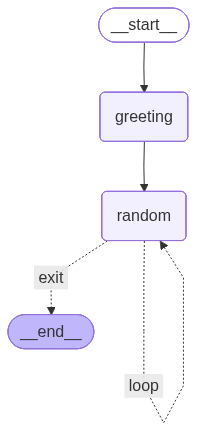

In [23]:
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
ip = AgentState(name="Nikhil", number=[], counter=0)
app.invoke(ip)

Entering loop: 1
Entering loop: 2
Entering loop: 3
Entering loop: 4


{'name': 'Hi there, Nikhil', 'number': [2, 10, 10, 9, 10], 'counter': 5}

## Guessing Exercise

In [31]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [56]:
def setup_node(state: AgentState) -> AgentState:
    """ Setup Node """
    state["player_name"] = f"Hi there, {state["player_name"]}"
    return state


def random_node(state: AgentState) -> AgentState:
    """ Generate a random guess between bounding limit"""
    guess = random.randint(state["lower_bound"], state["upper_bound"])
    state["guesses"].append(guess)
    if guess > 7:
        state["upper_bound"] = guess
    if guess < 7:
        state["lower_bound"] = guess
    state["attempts"] += 1
    return state


def should_continue(state: AgentState) -> AgentState:
    if state["attempts"] < 7 and state["guesses"][-1] !=7:
        print(f"Attempt:{state["attempts"]}, guessed:{state['guesses'][-1]}, upper_bound:{state['upper_bound']}, lower_bound:{state['lower_bound']}")
        return "loop"
    else:
        return "exit"

In [57]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("random", random_node)
graph.add_edge("setup", "random")
graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)
graph.set_entry_point("setup")
app = graph.compile()

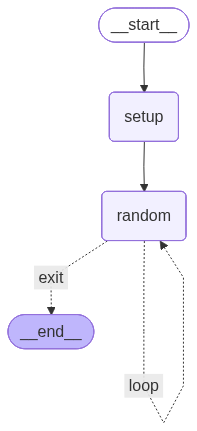

In [58]:
display(Image(app.get_graph().draw_mermaid_png()))

In [62]:
ip = AgentState(player_name="Nikhil", guesses=[], attempts=0, lower_bound=1, upper_bound=20)
app.invoke(ip)

Attempt:1, guessed:5, upper_bound:20, lower_bound:5
Attempt:2, guessed:20, upper_bound:20, lower_bound:5
Attempt:3, guessed:5, upper_bound:20, lower_bound:5
Attempt:4, guessed:19, upper_bound:19, lower_bound:5
Attempt:5, guessed:18, upper_bound:18, lower_bound:5
Attempt:6, guessed:11, upper_bound:11, lower_bound:5


{'player_name': 'Hi there, Nikhil',
 'guesses': [5, 20, 5, 19, 18, 11, 7],
 'attempts': 7,
 'lower_bound': 5,
 'upper_bound': 11}